## Importing the dependencies

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn import metrics


# Data collection and processing 

In [42]:
car_dataset = pd.read_csv("./sample_data/car data.csv")



# checking the number of rows and columns of the dataframe
car_dataset.shape


(301, 9)

In [43]:
# First 5 rows of the data frame

car_dataset.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [44]:
# getting the statistical values of the dataset

car_dataset.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [45]:
# getting some information about the dataset
car_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [46]:
# We can also check for null values in this way
car_dataset.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

In [47]:
# Checking the distribution of categorical data
print(car_dataset.Fuel_Type.value_counts())

print("=" * 50)

print(car_dataset.Seller_Type.value_counts())

print("=" * 50)

print(car_dataset.Transmission.value_counts())

Fuel_Type
Petrol    239
Diesel     60
CNG         2
Name: count, dtype: int64
Seller_Type
Dealer        195
Individual    106
Name: count, dtype: int64
Transmission
Manual       261
Automatic     40
Name: count, dtype: int64


# Encoding the categorical data 

In [48]:
# encoding the fuel type column
car_dataset.replace({
    'Fuel_Type': {
        'Petrol': 0,
        'Diesel': 1,
        'CNG': 2
    }
}, inplace=True)

C:\Users\USER\AppData\Local\Temp\ipykernel_9228\109189173.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  car_dataset.replace({


In [49]:
# encoding the seller type column
car_dataset.replace({
    'Seller_Type': {
        'Dealer': 0,
        'Individual': 1,
    }
}, inplace=True)

C:\Users\USER\AppData\Local\Temp\ipykernel_9228\2839132311.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  car_dataset.replace({


In [50]:
# encoding the transmission type column
car_dataset.replace({
    'Transmission': {
        'Manual': 0,
        'Automatic': 1,
    }
}, inplace=True)

C:\Users\USER\AppData\Local\Temp\ipykernel_9228\3455716113.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  car_dataset.replace({


In [51]:
car_dataset.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,0,0,0,0
1,sx4,2013,4.75,9.54,43000,1,0,0,0
2,ciaz,2017,7.25,9.85,6900,0,0,0,0
3,wagon r,2011,2.85,4.15,5200,0,0,0,0
4,swift,2014,4.60,6.87,42450,1,0,0,0


# splitting the dataset into Train and test data 

In [53]:
X = car_dataset.drop(['Car_Name', 'Selling_Price'], axis=1)
Y = car_dataset['Selling_Price']


print(X)
print(Y)

     Year  Present_Price  Kms_Driven  Fuel_Type  Seller_Type  Transmission  \
0    2014           5.59       27000          0            0             0   
1    2013           9.54       43000          1            0             0   
2    2017           9.85        6900          0            0             0   
3    2011           4.15        5200          0            0             0   
4    2014           6.87       42450          1            0             0   
..    ...            ...         ...        ...          ...           ...   
296  2016          11.60       33988          1            0             0   
297  2015           5.90       60000          0            0             0   
298  2009          11.00       87934          0            0             0   
299  2017          12.50        9000          1            0             0   
300  2016           5.90        5464          0            0             0   

     Owner  
0        0  
1        0  
2        0  
3        0 

In [54]:
# Splitting training and test data

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

# Model training

* Linear regression 


In [55]:
lin_reg_model = LinearRegression()

In [56]:
lin_reg_model.fit(X_train, Y_train)

LinearRegression()

# Model Evaluation 

In [59]:
#  Prediction on Training Data
training_data_prediction = lin_reg_model.predict(X_train)


In [63]:
# R squared Error
error_score = metrics.r2_score(Y_train, training_data_prediction)
print("R squared error:", error_score)

R squared error: 0.8838169193709792


# Visualize the actual prices and the predicted prices  

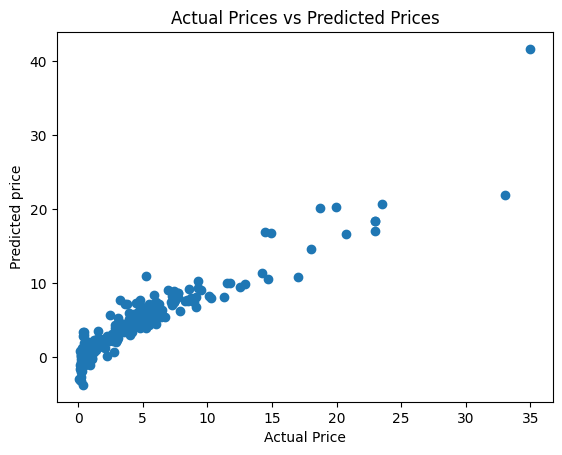

In [67]:
plt.scatter(Y_train, training_data_prediction)
plt.xlabel('Actual Price')
plt.ylabel('Predicted price')
plt.title("Actual Prices vs Predicted Prices")
plt.show()

In [70]:
# Prediction on Training data
test_data_prediction = lin_reg_model.predict(X_test)

In [71]:
# # R squared Error for test data
error_score = metrics.r2_score(Y_test, test_data_prediction)
print("R squared error:", error_score)

R squared error: 0.8401532365378521


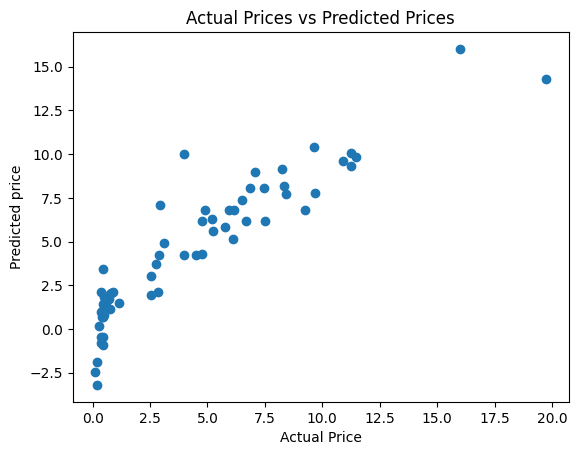

In [72]:
# Plotting the graph for test data
plt.scatter(Y_test, test_data_prediction)
plt.xlabel('Actual Price')
plt.ylabel('Predicted price')
plt.title("Actual Prices vs Predicted Prices")
plt.show()

* Lasso Regression 

In [ ]:

# Loading the lasso regression model
lasso_reg_model = Lasso()

In [74]:
lasso_reg_model.fit(X_train, Y_train)

Lasso()

# Model Evaluation 

In [76]:
#  Prediction on Training Data
training_data_prediction = lasso_reg_model.predict(X_train)


In [77]:
# R squared Error
error_score = metrics.r2_score(Y_train, training_data_prediction)
print("R squared error:", error_score)

R squared error: 0.843587395258283


Visualizing the prediction gotten from Lasso regression model 

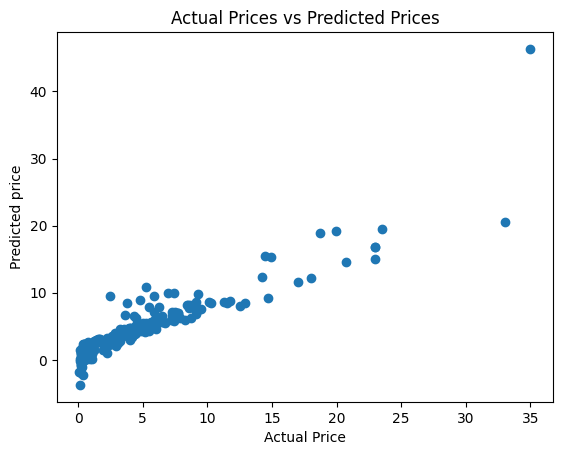

In [78]:
plt.scatter(Y_train, training_data_prediction)
plt.xlabel('Actual Price')
plt.ylabel('Predicted price')
plt.title("Actual Prices vs Predicted Prices")
plt.show()

In [79]:
# Prediction on Training data
test_data_prediction = lasso_reg_model.predict(X_test)

In [80]:
# # R squared Error for test data
error_score = metrics.r2_score(Y_test, test_data_prediction)
print("R squared error:", error_score)

R squared error: 0.8497457570738539


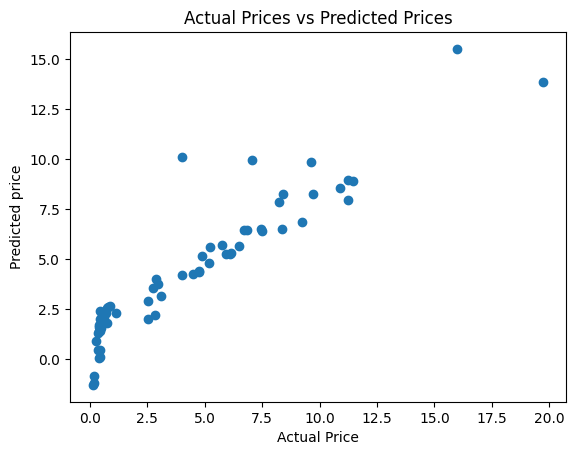

In [81]:
# Plotting the graph for test data
plt.scatter(Y_test, test_data_prediction)
plt.xlabel('Actual Price')
plt.ylabel('Predicted price')
plt.title("Actual Prices vs Predicted Prices")
plt.show()